# Đồ án KTDL - Notebook LOSOCV đầy đủ theo hướng paper

Notebook này phục vụ **Vai trò 3 - AI & Machine Learning (Hải Đăng)** theo hướng bám sát paper hơn.

Điểm khác biệt chính so với notebook train nhanh:
- không chia train/test một lần
- dùng **LOSOCV đầy đủ** ở mức subject
- mỗi vòng lặp sẽ bỏ lại 1 subject làm test
- xác suất được tính ở mức epoch rồi average lên subject-level


## 1. Mục tiêu và flow

Flow của notebook này:
1. Nạp bộ domain features đã tính sẵn.
2. Chọn bài toán nhị phân.
3. Chạy LOSOCV trên toàn bộ subject.
4. Trong moi fold:
   - rank feature bằng `class_distinctiveness`
   - train `FgMDM` trên từng feature
   - tạo stacked model
   - dự đoán subject test
5. Tổng hợp kết quả của toàn bộ folds.
6. Vẽ Confusion Matrix, ROC Curve và lưu bảng kết quả.

Lưu ý: notebook này sẽ chậm hơn notebook train nhanh vì chạy full LOSOCV.


In [1]:
from pathlib import Path
import json
import math
import os
import warnings

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyriemann.classification import FgMDM, class_distinctiveness
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore', category=FutureWarning)


## 2. Cấu hình notebook

Bạn có thể đổi bài toán, band, metric và tham số ở đây.

Mặc định notebook này dùng bộ feature có sẵn để bám sát Vai trò 3, không tính lại feature từ `.fif`.


In [2]:
ROOT = Path('/home/dohaidang/DataMining_Project')
PRECOMPUTED_DIR = ROOT / 'Full_MultiDomain_Features_Role3'
OUTPUT_DIR = ROOT / 'notebook_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_TAG = 'super_multidomain'

RANDOM_STATE = 42
INNER_FOLDS = 5
FGMDM_METRIC = 'euclid'
FGMDM_FALLBACK_METRICS = ('riemann',)
FILTER_RATIO = 0.5
ELASTICNET_ALPHA = 0.01
ELASTICNET_L1_RATIO = 0.15

PROBLEMS = {
    'ad_hc': ('A', 'C', 'AD', 'HC'),
    'ftd_hc': ('F', 'C', 'FTD', 'HC'),
    'ftd_ad': ('F', 'A', 'FTD', 'AD'),
}

SELECTED_PROBLEM = 'ad_hc'
SELECTED_BANDS = {'delta', 'theta', 'alpha', 'beta', 'gamma'}
SELECTED_METRICS = {'cov', 'corr', 'xcov', 'xcorr', 'csd', 'coh', 'mi', 'ecc', 'aecov', 'aecorr', 'plv', 'wplv'}
OUTER_LIMIT = None


## 3. Hàm nạp feature đã tính sẵn

Bộ hàm này giống notebook train nhanh, nhưng notebook này sẽ dùng nó cho full LOSOCV.


In [3]:
def normalize_subject_ids(subject_ids: np.ndarray) -> np.ndarray:
    normalized = []
    for subject_id in subject_ids.astype(str):
        if subject_id.startswith('sub-'):
            normalized.append(subject_id)
        else:
            normalized.append(f'sub-{subject_id.zfill(3)}')
    return np.asarray(normalized)


def nearest_spd_matrix(matrix: np.ndarray, jitter: float = 1e-6) -> np.ndarray:
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float64)
    symmetric = 0.5 * (matrix + matrix.T)
    eigvals, eigvecs = np.linalg.eigh(symmetric)
    eigvals = np.maximum(eigvals, jitter)
    stabilized = (eigvecs * eigvals) @ eigvecs.T
    stabilized = 0.5 * (stabilized + stabilized.T)
    stabilized += np.eye(stabilized.shape[0]) * jitter
    return stabilized


def stabilize_spd_stack(matrices: np.ndarray, jitter: float = 1e-6) -> np.ndarray:
    return np.stack([nearest_spd_matrix(matrix, jitter=jitter) for matrix in matrices]).astype(np.float64)


def discover_feature_names(precomputed_dir: Path, selected_bands: set[str], selected_metrics: set[str]) -> list[str]:
    feature_names = []
    for path in sorted(precomputed_dir.glob('*.npy')):
        if path.stem in {'labels', 'subject_ids', 'top_features_name'}:
            continue
        if '_' not in path.stem:
            continue
        band, metric = path.stem.split('_', maxsplit=1)
        if band in selected_bands and metric in selected_metrics:
            feature_names.append(path.stem)
    if not feature_names:
        raise ValueError('No matching feature files found. Check selected bands/metrics and PRECOMPUTED_DIR.')
    return feature_names


def load_precomputed_feature_catalog(precomputed_dir: Path, selected_bands: set[str], selected_metrics: set[str]):
    feature_names = discover_feature_names(precomputed_dir, selected_bands, selected_metrics)
    labels = np.load(precomputed_dir / 'labels.npy', allow_pickle=True).astype(str)
    subject_ids = normalize_subject_ids(np.load(precomputed_dir / 'subject_ids.npy', allow_pickle=True))

    catalog = {}
    for feature_name in feature_names:
        band, metric = feature_name.split('_', maxsplit=1)
        matrices = np.load(precomputed_dir / f'{feature_name}.npy', allow_pickle=True).astype(np.float64)
        matrices = stabilize_spd_stack(matrices)
        catalog[f'{band}__{metric}'] = {
            'band': band,
            'metric': metric,
            'matrices': matrices,
            'labels': labels,
            'subject_ids': subject_ids,
            'spd_stabilized': True,
        }
    return catalog


In [4]:
feature_catalog = load_precomputed_feature_catalog(
    PRECOMPUTED_DIR,
    selected_bands=SELECTED_BANDS,
    selected_metrics=SELECTED_METRICS,
)

print('So feature da nap:', len(feature_catalog))
for key in sorted(feature_catalog):
    print(' -', key, feature_catalog[key]['matrices'].shape)


So feature da nap: 60
 - alpha__aecorr (13422, 19, 19)
 - alpha__aecov (13422, 19, 19)
 - alpha__coh (13422, 19, 19)
 - alpha__corr (13422, 19, 19)
 - alpha__cov (13422, 19, 19)
 - alpha__csd (13422, 19, 19)
 - alpha__ecc (13422, 19, 19)
 - alpha__mi (13422, 19, 19)
 - alpha__plv (13422, 19, 19)
 - alpha__wplv (13422, 19, 19)
 - alpha__xcorr (13422, 19, 19)
 - alpha__xcov (13422, 19, 19)
 - beta__aecorr (13422, 19, 19)
 - beta__aecov (13422, 19, 19)
 - beta__coh (13422, 19, 19)
 - beta__corr (13422, 19, 19)
 - beta__cov (13422, 19, 19)
 - beta__csd (13422, 19, 19)
 - beta__ecc (13422, 19, 19)
 - beta__mi (13422, 19, 19)
 - beta__plv (13422, 19, 19)
 - beta__wplv (13422, 19, 19)
 - beta__xcorr (13422, 19, 19)
 - beta__xcov (13422, 19, 19)
 - delta__aecorr (13422, 19, 19)
 - delta__aecov (13422, 19, 19)
 - delta__coh (13422, 19, 19)
 - delta__corr (13422, 19, 19)
 - delta__cov (13422, 19, 19)
 - delta__csd (13422, 19, 19)
 - delta__ecc (13422, 19, 19)
 - delta__mi (13422, 19, 19)
 - delt

## 4. Kiểm tra nhanh labels và subject IDs

Bước này giúp chắc rằng dữ liệu đầu vào hợp lệ trước khi chạy LOSOCV.


In [5]:
sample_feature = next(iter(feature_catalog.values()))
epoch_df = pd.DataFrame({
    'subject_id': sample_feature['subject_ids'],
    'label': sample_feature['labels'],
})
subject_df = epoch_df.drop_duplicates('subject_id').reset_index(drop=True)
subject_df['epoch_count'] = subject_df['subject_id'].map(epoch_df['subject_id'].value_counts())

display(epoch_df['label'].value_counts().rename('epoch_count').to_frame())
display(subject_df['label'].value_counts().rename('subject_count').to_frame())
display(subject_df.head())


,epoch_count
label,
A,5666
C,4603
F,3153


,subject_count
label,
A,36
C,29
F,23


,subject_id,label,epoch_count
0,sub-001,A,119
1,sub-002,A,158
2,sub-003,A,61
3,sub-004,A,135
4,sub-005,A,135


## 5. Hàm hỗ trợ cho LOSOCV

Nhóm hàm này được viết riêng để phục vụ quy trình cross-validation đầy đủ ở mức subject.


In [6]:
def binary_subset(feature_item, positive_code: str, negative_code: str):
    mask = np.isin(feature_item['labels'], [positive_code, negative_code])
    matrices = feature_item['matrices'][mask]
    if not feature_item.get('spd_stabilized', False):
        matrices = stabilize_spd_stack(matrices)
    labels = (feature_item['labels'][mask] == positive_code).astype(int)
    subjects = feature_item['subject_ids'][mask]
    return matrices, labels, subjects


def build_subject_frame(labels: np.ndarray, subject_ids: np.ndarray):
    frame = pd.DataFrame({'subject_id': subject_ids, 'label': labels})
    subject_frame = frame.drop_duplicates('subject_id').sort_values('subject_id').reset_index(drop=True)
    counts = frame.groupby('subject_id').size().rename('epoch_count')
    subject_frame = subject_frame.merge(counts, on='subject_id', how='left')
    subject_frame['sample_weight'] = 1.0 / subject_frame['epoch_count']
    return subject_frame


def epoch_weights(subject_ids: np.ndarray) -> np.ndarray:
    counts = pd.Series(subject_ids).value_counts()
    return np.asarray([1.0 / counts[sid] for sid in subject_ids], dtype=np.float64)


def safe_inner_folds(labels: np.ndarray, requested_folds: int) -> int:
    class_counts = np.bincount(labels.astype(int))
    min_count = int(class_counts.min())
    if min_count < 2:
        raise ValueError('At least two subjects per class are required for inner cross-validation.')
    return int(min(requested_folds, min_count))


def aggregate_probs_by_subject(probabilities: np.ndarray, subject_ids: np.ndarray) -> pd.Series:
    frame = pd.DataFrame({'subject_id': subject_ids, 'probability': probabilities})
    return frame.groupby('subject_id')['probability'].mean()


def evaluate_subject_predictions(y_true: np.ndarray, y_prob: np.ndarray):
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics = {
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred)),
        'sensitivity': float(tp / (tp + fn) if (tp + fn) else 0.0),
        'specificity': float(tn / (tn + fp) if (tn + fp) else 0.0),
    }
    return metrics, y_pred


def build_meta_model(alpha: float, l1_ratio: float, random_state: int) -> LogisticRegression:
    return LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=l1_ratio,
        C=1.0 / alpha,
        max_iter=3000,
        random_state=random_state,
    )


def fit_fgmdm_with_fallback(X_train: np.ndarray, y_train: np.ndarray, sample_weight: np.ndarray):
    last_error = None
    for metric in (FGMDM_METRIC, *FGMDM_FALLBACK_METRICS):
        try:
            model = FgMDM(metric=metric)
            model.fit(X_train, y_train, sample_weight=sample_weight)
            return model, metric
        except ValueError as exc:
            last_error = exc
    raise last_error


def safe_class_distinctiveness(X: np.ndarray, y: np.ndarray):
    last_error = None
    for metric in (FGMDM_METRIC, *FGMDM_FALLBACK_METRICS):
        try:
            return float(class_distinctiveness(X, y, metric=metric)), metric
        except ValueError as exc:
            last_error = exc
    raise last_error


def predict_positive_proba(model, X: np.ndarray, positive_label: int = 1) -> np.ndarray:
    class_index = int(np.where(model.classes_ == positive_label)[0][0])
    return model.predict_proba(X)[:, class_index]


## 6. Chọn bài toán và tạo bảng subject-level

Cell này xác định danh sách subject sẽ được đưa vào LOSOCV.


In [7]:
positive_code, negative_code, positive_name, negative_name = PROBLEMS[SELECTED_PROBLEM]
reference_feature = next(iter(feature_catalog.values()))
_, y_binary, subject_ids_binary = binary_subset(reference_feature, positive_code, negative_code)
subject_table = build_subject_frame(y_binary, subject_ids_binary)

if OUTER_LIMIT is not None:
    subject_table = subject_table.iloc[:OUTER_LIMIT].copy().reset_index(drop=True)

print('Bai toan:', SELECTED_PROBLEM, f'({positive_name} vs {negative_name})')
print('Tong so subject duoc dung trong LOSOCV:', len(subject_table))
display(subject_table['label'].value_counts().rename('subject_count').to_frame())
display(subject_table.head())


Bai toan: ad_hc (AD vs HC)
Tong so subject duoc dung trong LOSOCV: 65


,subject_count
label,
1,36
0,29


,subject_id,label,epoch_count,sample_weight
0,sub-001,1,119,0.008403
1,sub-002,1,158,0.006329
2,sub-003,1,61,0.016393
3,sub-004,1,135,0.007407
4,sub-005,1,135,0.007407


## 7. Hàm train base model trên từng feature trong mỗi fold

Mỗi feature sẽ được train bằng `FgMDM`, sau đó sinh ra xác suất theo epoch và average lên subject.


In [8]:
def fit_base_oof_predictions(feature_item, positive_code: str, negative_code: str, train_subject_ids: set[str], test_subject_id: str):
    X, y, subjects = binary_subset(feature_item, positive_code, negative_code)
    train_mask = np.isin(subjects, list(train_subject_ids))
    test_mask = subjects == test_subject_id

    X_train, y_train, s_train = X[train_mask], y[train_mask], subjects[train_mask]
    X_test, y_test, s_test = X[test_mask], y[test_mask], subjects[test_mask]

    train_subject_frame = build_subject_frame(y_train, s_train)
    inner_splits = safe_inner_folds(train_subject_frame['label'].to_numpy(), INNER_FOLDS)
    inner_cv = StratifiedGroupKFold(n_splits=inner_splits, shuffle=True, random_state=RANDOM_STATE)
    sample_weight = epoch_weights(s_train)

    oof_epoch_prob = np.empty(y_train.shape[0], dtype=np.float64)
    for inner_train_idx, inner_valid_idx in inner_cv.split(X_train, y_train, s_train):
        model, _ = fit_fgmdm_with_fallback(
            X_train[inner_train_idx],
            y_train[inner_train_idx],
            sample_weight[inner_train_idx],
        )
        oof_epoch_prob[inner_valid_idx] = predict_positive_proba(model, X_train[inner_valid_idx])

    oof_subject_prob = aggregate_probs_by_subject(oof_epoch_prob, s_train)
    oof_subject_prob = oof_subject_prob.reindex(train_subject_frame['subject_id']).to_numpy()

    final_model, final_metric = fit_fgmdm_with_fallback(X_train, y_train, sample_weight)
    test_epoch_prob = predict_positive_proba(final_model, X_test)
    test_subject_prob = aggregate_probs_by_subject(test_epoch_prob, s_test)

    return oof_subject_prob, float(test_subject_prob.loc[test_subject_id]), final_metric


## 8. Hàm wrapper feature selection cho stacked model

Cell này chọn tập feature tốt nhất cho meta-model thông qua forward greedy selection.


In [9]:
def meta_score(X: np.ndarray, y: np.ndarray, sample_weight: np.ndarray, selected_columns: list[int]) -> float:
    n_splits = safe_inner_folds(y, INNER_FOLDS)
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, valid_idx in splitter.split(X[:, selected_columns], y):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X[train_idx][:, selected_columns])
        X_valid_scaled = scaler.transform(X[valid_idx][:, selected_columns])
        model = build_meta_model(ELASTICNET_ALPHA, ELASTICNET_L1_RATIO, RANDOM_STATE)
        model.fit(X_train_scaled, y[train_idx], sample_weight=sample_weight[train_idx])
        valid_prob = predict_positive_proba(model, X_valid_scaled)
        scores.append(roc_auc_score(y[valid_idx], valid_prob))
    return float(np.mean(scores))


def greedy_wrapper_selection(X: np.ndarray, y: np.ndarray, sample_weight: np.ndarray) -> list[int]:
    selected = []
    remaining = list(range(X.shape[1]))
    best_score = -math.inf
    while remaining:
        trial_scores = []
        for candidate in remaining:
            score = meta_score(X, y, sample_weight, selected + [candidate])
            trial_scores.append((score, candidate))
        trial_scores.sort(reverse=True)
        candidate_score, candidate_idx = trial_scores[0]
        if not selected or candidate_score > best_score:
            selected.append(candidate_idx)
            remaining.remove(candidate_idx)
            best_score = candidate_score
        else:
            break
    return selected


## 9. Hàm chạy LOSOCV đầy đủ cho stacked model

Đây là hàm trung tâm của notebook.
Mỗi fold sẽ:
- bỏ lại 1 subject làm test
- rank feature bằng `class_distinctiveness`
- train `FgMDM` trên từng feature
- train meta-model
- lưu xác suất và feature được chọn


In [10]:
def run_losocv_stacked_model(problem_name: str, subject_table: pd.DataFrame):
    positive_code, negative_code, positive_name, negative_name = PROBLEMS[problem_name]
    outer_predictions = []
    fold_artifacts = []

    for fold_idx, test_row in subject_table.iterrows():
        test_subject_id = str(test_row['subject_id'])
        train_subject_table = subject_table[subject_table['subject_id'] != test_subject_id].reset_index(drop=True)
        train_subject_ids = set(train_subject_table['subject_id'])

        distinctiveness_scores = {}
        for name, feature_item in feature_catalog.items():
            X, y, subjects = binary_subset(feature_item, positive_code, negative_code)
            train_mask = np.isin(subjects, list(train_subject_ids))
            score, _ = safe_class_distinctiveness(X[train_mask], y[train_mask])
            distinctiveness_scores[name] = score

        ranked = sorted(distinctiveness_scores.items(), key=lambda item: item[1], reverse=True)
        retain_count = max(1, int(math.ceil(len(ranked) * FILTER_RATIO)))
        retained_features = [name for name, _ in ranked[:retain_count]]

        meta_columns_train = []
        meta_columns_test = []
        feature_fit_metrics = {}
        for feature_name in retained_features:
            oof_subject_prob, test_subject_prob, fit_metric = fit_base_oof_predictions(
                feature_catalog[feature_name],
                positive_code,
                negative_code,
                train_subject_ids,
                test_subject_id,
            )
            feature_fit_metrics[feature_name] = fit_metric
            meta_columns_train.append(oof_subject_prob)
            meta_columns_test.append(test_subject_prob)

        X_meta_train = np.column_stack(meta_columns_train)
        y_meta_train = train_subject_table['label'].to_numpy()
        sample_weight = train_subject_table['sample_weight'].to_numpy(dtype=np.float64)

        selected_indices = greedy_wrapper_selection(X_meta_train, y_meta_train, sample_weight)
        if not selected_indices:
            selected_indices = [0]

        scaler = StandardScaler()
        X_meta_train_selected = scaler.fit_transform(X_meta_train[:, selected_indices])
        meta_model = build_meta_model(ELASTICNET_ALPHA, ELASTICNET_L1_RATIO, RANDOM_STATE)
        meta_model.fit(X_meta_train_selected, y_meta_train, sample_weight=sample_weight)

        X_meta_test = np.asarray(meta_columns_test, dtype=np.float64)[selected_indices].reshape(1, -1)
        X_meta_test_scaled = scaler.transform(X_meta_test)
        test_prob = float(predict_positive_proba(meta_model, X_meta_test_scaled)[0])

        outer_predictions.append({
            'subject_id': test_subject_id,
            'y_true': int(test_row['label']),
            'y_prob': test_prob,
        })
        fold_artifacts.append({
            'fold_index': int(fold_idx),
            'test_subject_id': test_subject_id,
            'retained_features': retained_features,
            'selected_features': [retained_features[idx] for idx in selected_indices],
            'feature_fit_metrics': feature_fit_metrics,
            'top_distinctiveness': ranked[:10],
        })

    predictions_df = pd.DataFrame(outer_predictions)
    metrics, y_pred = evaluate_subject_predictions(predictions_df['y_true'].to_numpy(), predictions_df['y_prob'].to_numpy())
    return predictions_df, fold_artifacts, metrics, y_pred


## 10. Chạy LOSOCV đầy đủ

Cell này có thể tốn khá nhiều thời gian nếu bạn dùng tất cả feature và tất cả subject.


In [11]:
predictions_df, fold_artifacts, final_metrics, final_pred = run_losocv_stacked_model(
    problem_name=SELECTED_PROBLEM,
    subject_table=subject_table,
)

pd.DataFrame([final_metrics], index=['losocv_stacked_model'])


,roc_auc,accuracy,f1,sensitivity,specificity
losocv_stacked_model,0.822797,0.738462,0.773333,0.805556,0.655172


## 11. Kiểm tra dự đoán theo subject

Bảng này là output quan trọng để viết phần Results và để đối chiếu subject-level prediction.


In [12]:
predictions_df.head(10)


,subject_id,y_true,y_prob
0,sub-001,1,0.861738
1,sub-002,1,0.742925
2,sub-003,1,0.222116
3,sub-004,1,0.914067
4,sub-005,1,0.691472
5,sub-006,1,0.301181
6,sub-007,1,0.814045
7,sub-008,1,0.823534
8,sub-009,1,0.887871
9,sub-010,1,0.649143


## 12. Vẽ Confusion Matrix và ROC Curve

Phần này bám sát yêu cầu paper/slides của đồ án.


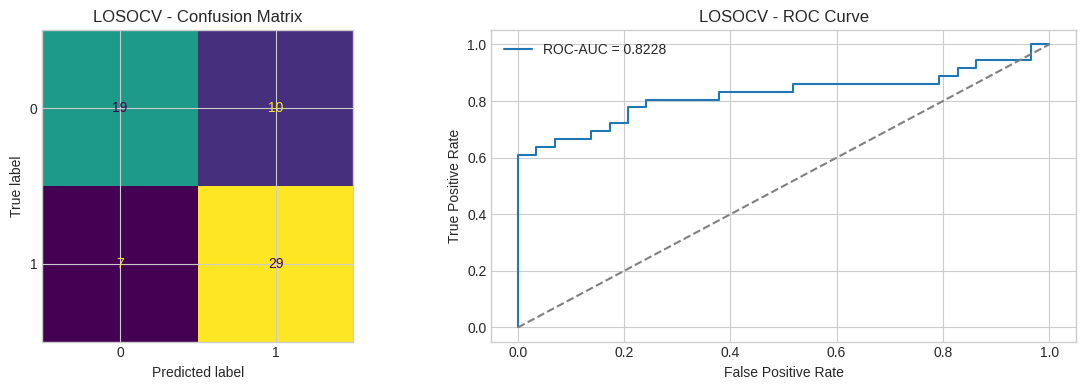

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    predictions_df['y_true'].to_numpy(),
    final_pred,
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title('LOSOCV - Confusion Matrix')

fpr, tpr, _ = roc_curve(predictions_df['y_true'].to_numpy(), predictions_df['y_prob'].to_numpy())
auc_value = roc_auc_score(predictions_df['y_true'].to_numpy(), predictions_df['y_prob'].to_numpy())
axes[1].plot(fpr, tpr, label=f'ROC-AUC = {auc_value:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('LOSOCV - ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()


## 13. Xem feature được chọn trong các fold

Cell này giúp bạn phân tích feature nào hay được chọn nhất trong stacked model.


In [14]:
selected_features_all = []
for item in fold_artifacts:
    selected_features_all.extend(item['selected_features'])

selected_feature_counts = pd.Series(selected_features_all).value_counts().rename('selected_count')
selected_feature_counts.to_frame()


,selected_count
beta__corr,51
theta__ecc,28
alpha__plv,24
alpha__aecorr,17
alpha__ecc,15
alpha__corr,15
alpha__wplv,7
theta__corr,6
alpha__coh,5
alpha__mi,4


## 14. Lưu kết quả LOSOCV

Kết quả được lưu thành file CSV và JSON để phục vụ viết báo cáo, đối chiếu slide, hoặc tái sử dụng sau này.


In [15]:
metrics_path = OUTPUT_DIR / f'{OUTPUT_TAG}_{SELECTED_PROBLEM}_losocv_metrics.csv'
predictions_path = OUTPUT_DIR / f'{OUTPUT_TAG}_{SELECTED_PROBLEM}_losocv_subject_predictions.csv'
folds_path = OUTPUT_DIR / f'{OUTPUT_TAG}_{SELECTED_PROBLEM}_losocv_fold_artifacts.json'

pd.DataFrame([final_metrics], index=['losocv_stacked_model']).to_csv(metrics_path)
predictions_df.to_csv(predictions_path, index=False)
folds_path.write_text(json.dumps(fold_artifacts, indent=2))

print('Da luu:')
print(' -', metrics_path)
print(' -', predictions_path)
print(' -', folds_path)


Da luu:
 - /home/dohaidang/DataMining_Project/notebook_outputs/super_multidomain_ad_hc_losocv_metrics.csv
 - /home/dohaidang/DataMining_Project/notebook_outputs/super_multidomain_ad_hc_losocv_subject_predictions.csv
 - /home/dohaidang/DataMining_Project/notebook_outputs/super_multidomain_ad_hc_losocv_fold_artifacts.json


## 15. Chạy đủ 3 bài toán nhị phân

Phần này mở rộng notebook từ 1 bài toán sang đúng flow báo cáo:
- `ad_hc`: AD vs Healthy Control
- `ftd_hc`: FTD vs Healthy Control
- `ftd_ad`: FTD vs AD

Mỗi bài toán vẫn dùng LOSOCV ở mức subject. Nếu file kết quả đã tồn tại trong `notebook_outputs/`, notebook sẽ đọc lại để tiết kiệm thời gian. Nếu chưa có, notebook sẽ chạy LOSOCV và lưu kết quả mới.


In [16]:
USE_CACHED_RESULTS = False
ALL_PROBLEMS = ['ad_hc', 'ftd_hc', 'ftd_ad']


def build_subject_table_for_problem(problem_name: str) -> pd.DataFrame:
    positive_code, negative_code, _, _ = PROBLEMS[problem_name]
    reference_feature = next(iter(feature_catalog.values()))
    _, y_binary, subject_ids_binary = binary_subset(reference_feature, positive_code, negative_code)
    return build_subject_frame(y_binary, subject_ids_binary)


def result_paths(problem_name: str):
    return {
        'metrics': OUTPUT_DIR / f'{OUTPUT_TAG}_{problem_name}_losocv_metrics.csv',
        'predictions': OUTPUT_DIR / f'{OUTPUT_TAG}_{problem_name}_losocv_subject_predictions.csv',
        'folds': OUTPUT_DIR / f'{OUTPUT_TAG}_{problem_name}_losocv_fold_artifacts.json',
    }


def load_or_run_problem(problem_name: str):
    paths = result_paths(problem_name)
    if USE_CACHED_RESULTS and all(path.exists() for path in paths.values()):
        metrics = pd.read_csv(paths['metrics'], index_col=0).iloc[0].to_dict()
        predictions = pd.read_csv(paths['predictions'])
        folds = json.loads(paths['folds'].read_text())
        print(f'Loaded cached result: {problem_name}')
        return predictions, folds, metrics

    problem_subject_table = build_subject_table_for_problem(problem_name)
    predictions, folds, metrics, _ = run_losocv_stacked_model(
        problem_name=problem_name,
        subject_table=problem_subject_table,
    )

    pd.DataFrame([metrics], index=['losocv_stacked_model']).to_csv(paths['metrics'])
    predictions.to_csv(paths['predictions'], index=False)
    paths['folds'].write_text(json.dumps(folds, indent=2))
    print(f'Ran and saved result: {problem_name}')
    return predictions, folds, metrics


all_results = {}
for problem_name in ALL_PROBLEMS:
    predictions, folds, metrics = load_or_run_problem(problem_name)
    all_results[problem_name] = {
        'predictions': predictions,
        'folds': folds,
        'metrics': metrics,
    }


Ran and saved result: ad_hc
Ran and saved result: ftd_hc


/home/dohaidang/.local/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dohaidang/.local/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dohaidang/.local/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dohaidang/.local/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dohaidang/.local/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dohaidang/.local/lib/python3.14/site-packages/sklearn/linea

Ran and saved result: ftd_ad


## 16. Bảng tổng hợp và trung bình kết quả

Cell này tạo bảng tổng hợp cho 3 bài toán và tính trung bình các metric. Đây là bảng nên đưa vào phần Results của báo cáo.


In [17]:
metrics_summary = pd.DataFrame({
    problem_name: result['metrics']
    for problem_name, result in all_results.items()
}).T

metrics_summary.index.name = 'problem'
metrics_summary.loc['mean'] = metrics_summary.mean(numeric_only=True)
metrics_summary


,roc_auc,accuracy,f1,sensitivity,specificity
problem,,,,,
ad_hc,0.822797,0.738462,0.773333,0.805556,0.655172
ftd_hc,0.737631,0.673077,0.622222,0.608696,0.724138
ftd_ad,0.592995,0.525424,0.222222,0.173913,0.750000
mean,0.717808,0.645654,0.539259,0.529388,0.709770


In [18]:
summary_path = OUTPUT_DIR / f'{OUTPUT_TAG}_all_binary_losocv_metrics_summary.csv'
metrics_summary.to_csv(summary_path)
print('Da luu bang tong hop:', summary_path)


Da luu bang tong hop: /home/dohaidang/DataMining_Project/notebook_outputs/super_multidomain_all_binary_losocv_metrics_summary.csv


## 17. Biểu đồ so sánh metric giữa 3 bài toán

Biểu đồ này dùng để nhìn nhanh bài toán nào dễ/khó hơn. Theo paper, AD/HC thường tốt nhất, FTD/AD thường khó nhất.


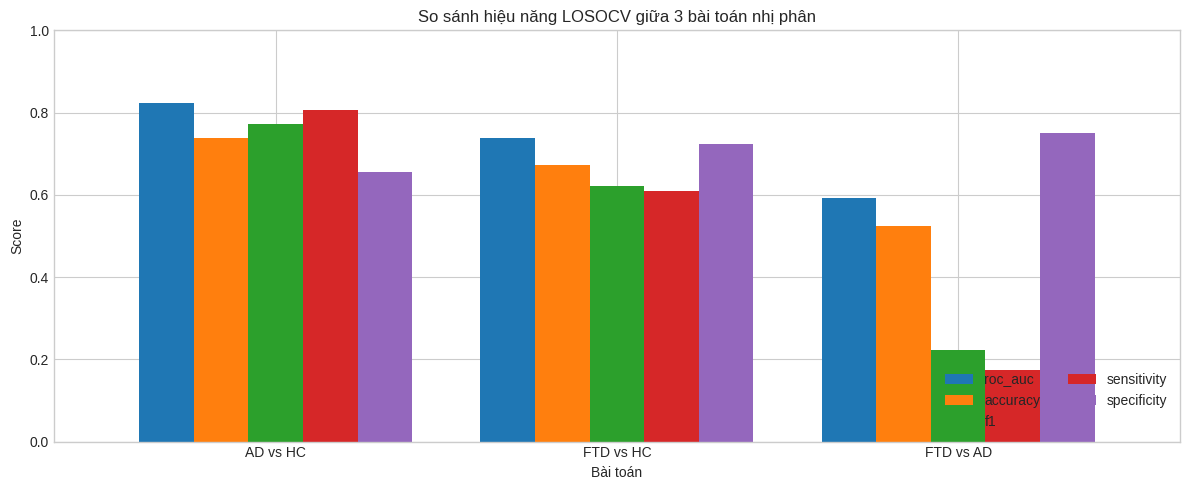

In [19]:
plot_metrics = ['roc_auc', 'accuracy', 'f1', 'sensitivity', 'specificity']
problem_labels = {
    'ad_hc': 'AD vs HC',
    'ftd_hc': 'FTD vs HC',
    'ftd_ad': 'FTD vs AD',
}

ax = metrics_summary.drop(index='mean')[plot_metrics].rename(index=problem_labels).plot(
    kind='bar',
    figsize=(12, 5),
    ylim=(0, 1),
    width=0.8,
)
ax.set_title('So sánh hiệu năng LOSOCV giữa 3 bài toán nhị phân')
ax.set_xlabel('Bài toán')
ax.set_ylabel('Score')
ax.legend(loc='lower right', ncol=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 18. Mô phỏng Fig. 5 - ROC curves cho stacked ensemble

Paper có Fig. 5 trình bày ROC curves của stacked ensemble cho các bài toán. Cell này vẽ lại theo cùng ý tưởng bằng kết quả LOSOCV của project.


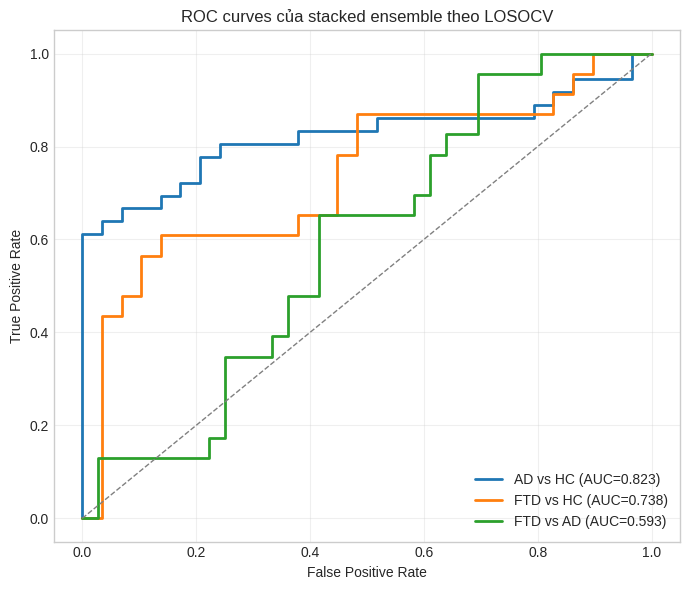

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))

for problem_name, result in all_results.items():
    predictions = result['predictions']
    fpr, tpr, _ = roc_curve(predictions['y_true'], predictions['y_prob'])
    auc_value = roc_auc_score(predictions['y_true'], predictions['y_prob'])
    ax.plot(fpr, tpr, linewidth=2, label=f"{problem_labels[problem_name]} (AUC={auc_value:.3f})")

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_title('ROC curves của stacked ensemble theo LOSOCV')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 19. Confusion Matrix cho từng bài toán

Mỗi confusion matrix được tính ở mức subject. Ngưỡng mặc định là `0.5` trên xác suất lớp dương.


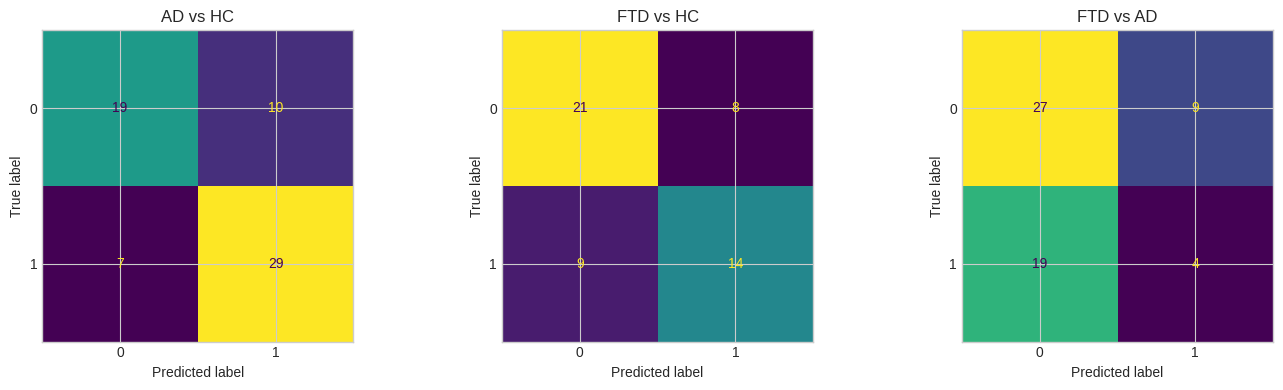

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (problem_name, result) in zip(axes, all_results.items()):
    predictions = result['predictions'].copy()
    predictions['y_pred'] = (predictions['y_prob'] >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        predictions['y_true'],
        predictions['y_pred'],
        ax=ax,
        colorbar=False,
    )
    ax.set_title(problem_labels[problem_name])

plt.tight_layout()
plt.show()


## 20. So sánh ROC-AUC với paper

Các giá trị paper dùng để đối chiếu là kết quả stacked ensemble LOSOCV được mô tả trong bài báo:
- AD/HC: 81.80%
- FTD/HC: 71.36%
- AD/FTD: 65.10%

Lưu ý: project hiện tại dùng bộ feature đã tính sẵn trong `Super_MultiDomain_Features_Role3`, nên không hoàn toàn giống 100% feature set của paper.


In [22]:
paper_auc = pd.Series({
    'ad_hc': 0.8180,
    'ftd_hc': 0.7136,
    'ftd_ad': 0.6510,
}, name='paper_auc')

comparison_auc = pd.DataFrame({
    'project_auc': metrics_summary.drop(index='mean')['roc_auc'],
    'paper_auc': paper_auc,
})
comparison_auc.index = comparison_auc.index.map(problem_labels)
comparison_auc['difference_project_minus_paper'] = comparison_auc['project_auc'] - comparison_auc['paper_auc']
comparison_auc


,project_auc,paper_auc,difference_project_minus_paper
AD vs HC,0.822797,0.8180,0.004797
FTD vs HC,0.737631,0.7136,0.024031
FTD vs AD,0.592995,0.6510,-0.058005


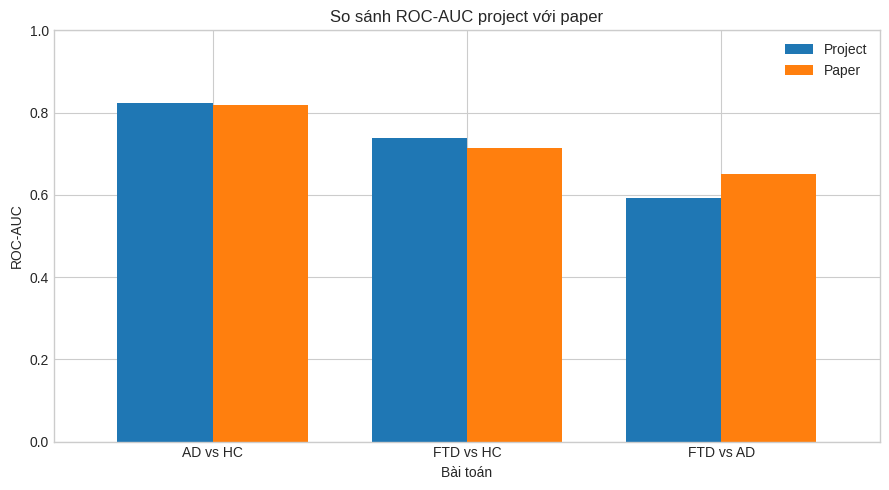

In [23]:
ax = comparison_auc[['project_auc', 'paper_auc']].plot(
    kind='bar',
    figsize=(9, 5),
    ylim=(0, 1),
    width=0.75,
)
ax.set_title('So sánh ROC-AUC project với paper')
ax.set_xlabel('Bài toán')
ax.set_ylabel('ROC-AUC')
ax.legend(['Project', 'Paper'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 21. Feature được chọn trong stacked model

Cell này tổng hợp các feature thường được wrapper selection chọn nhất. Đây là phần mô phỏng tinh thần phân tích feature importance của paper, nhưng dùng chính kết quả trong notebook.


In [24]:
feature_selection_rows = []
for problem_name, result in all_results.items():
    for fold in result['folds']:
        for feature_name in fold.get('selected_features', []):
            feature_selection_rows.append({
                'problem': problem_name,
                'feature': feature_name,
            })

feature_selection_df = pd.DataFrame(feature_selection_rows)
feature_selection_counts = (
    feature_selection_df
    .value_counts(['problem', 'feature'])
    .rename('selected_count')
    .reset_index()
)

feature_selection_pivot = feature_selection_counts.pivot(
    index='feature',
    columns='problem',
    values='selected_count',
).fillna(0).astype(int)

feature_selection_pivot = feature_selection_pivot.rename(columns=problem_labels)
feature_selection_pivot


problem,AD vs HC,FTD vs AD,FTD vs HC
feature,,,
alpha__aecorr,17,0,16
alpha__coh,5,1,0
alpha__corr,15,15,3
alpha__ecc,15,1,21
alpha__mi,4,16,6
alpha__plv,24,29,7
alpha__wplv,7,18,6
alpha__xcorr,2,0,12
beta__aecorr,0,0,3


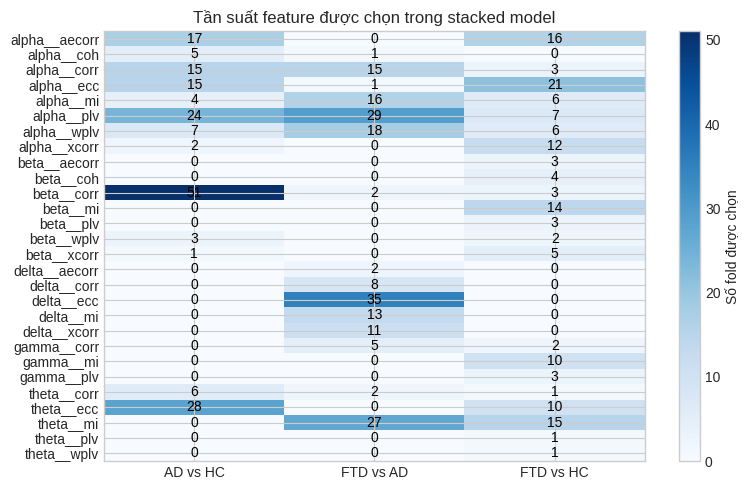

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(feature_selection_pivot.to_numpy(), aspect='auto', cmap='Blues')

ax.set_xticks(range(feature_selection_pivot.shape[1]))
ax.set_xticklabels(feature_selection_pivot.columns, rotation=0)
ax.set_yticks(range(feature_selection_pivot.shape[0]))
ax.set_yticklabels(feature_selection_pivot.index)
ax.set_title('Tần suất feature được chọn trong stacked model')

for i in range(feature_selection_pivot.shape[0]):
    for j in range(feature_selection_pivot.shape[1]):
        value = feature_selection_pivot.iloc[i, j]
        ax.text(j, i, str(value), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, label='Số fold được chọn')
plt.tight_layout()
plt.show()


## 22. Mô phỏng Fig. 2 - heatmap ROC-AUC của base classifiers (tuỳ chọn)

Paper có Fig. 2 là heatmap ROC-AUC cho từng band và connectivity metric. Cell dưới đây mô phỏng lại bằng các feature hiện có trong folder precomputed.

Phần này có thể tốn thêm thời gian vì phải chạy LOSOCV cho từng feature riêng lẻ. Mặc định `RUN_BASE_HEATMAP = False`; đổi thành `True` nếu cần tạo heatmap này cho báo cáo.


In [ ]:
RUN_BASE_HEATMAP = False


def run_base_feature_losocv(problem_name: str, feature_name: str) -> float:
    positive_code, negative_code, _, _ = PROBLEMS[problem_name]
    problem_subject_table = build_subject_table_for_problem(problem_name)
    feature_item = feature_catalog[feature_name]
    predictions = []

    for _, test_row in problem_subject_table.iterrows():
        test_subject_id = str(test_row['subject_id'])
        train_subject_ids = set(problem_subject_table.loc[problem_subject_table['subject_id'] != test_subject_id, 'subject_id'])
        X, y, subjects = binary_subset(feature_item, positive_code, negative_code)
        train_mask = np.isin(subjects, list(train_subject_ids))
        test_mask = subjects == test_subject_id

        X_train, y_train, s_train = X[train_mask], y[train_mask], subjects[train_mask]
        X_test, s_test = X[test_mask], subjects[test_mask]
        model, _ = fit_fgmdm_with_fallback(X_train, y_train, epoch_weights(s_train))
        test_epoch_prob = predict_positive_proba(model, X_test)
        test_subject_prob = aggregate_probs_by_subject(test_epoch_prob, s_test).loc[test_subject_id]
        predictions.append({'y_true': int(test_row['label']), 'y_prob': float(test_subject_prob)})

    prediction_df = pd.DataFrame(predictions)
    return float(roc_auc_score(prediction_df['y_true'], prediction_df['y_prob']))


if RUN_BASE_HEATMAP:
    base_auc_rows = []
    for problem_name in ALL_PROBLEMS:
        for feature_name, feature_item in feature_catalog.items():
            auc_value = run_base_feature_losocv(problem_name, feature_name)
            base_auc_rows.append({
                'problem': problem_name,
                'feature': feature_name,
                'band': feature_item['band'],
                'metric': feature_item['metric'],
                'roc_auc': auc_value,
            })
    base_auc_df = pd.DataFrame(base_auc_rows)
    base_auc_df.to_csv(OUTPUT_DIR / 'base_feature_losocv_auc.csv', index=False)
else:
    base_auc_path = OUTPUT_DIR / 'base_feature_losocv_auc.csv'
    base_auc_df = pd.read_csv(base_auc_path) if base_auc_path.exists() else pd.DataFrame()

base_auc_df.head()


""


In [27]:
if not base_auc_df.empty:
    fig, axes = plt.subplots(1, len(ALL_PROBLEMS), figsize=(15, 4), sharey=True)
    for ax, problem_name in zip(axes, ALL_PROBLEMS):
        problem_auc = base_auc_df[base_auc_df['problem'] == problem_name]
        heatmap_data = problem_auc.pivot(index='band', columns='metric', values='roc_auc').sort_index()
        im = ax.imshow(heatmap_data.to_numpy(), vmin=0, vmax=1, cmap='viridis', aspect='auto')
        ax.set_title(problem_labels[problem_name])
        ax.set_xticks(range(len(heatmap_data.columns)))
        ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')
        ax.set_yticks(range(len(heatmap_data.index)))
        ax.set_yticklabels(heatmap_data.index)
        for i in range(heatmap_data.shape[0]):
            for j in range(heatmap_data.shape[1]):
                value = heatmap_data.iloc[i, j]
                if pd.notna(value):
                    ax.text(j, i, f'{value:.2f}', ha='center', va='center', color='white')
    fig.colorbar(im, ax=axes, label='ROC-AUC')
    plt.tight_layout()
    plt.show()
else:
    print('Chua co base_auc_df. Doi RUN_BASE_HEATMAP = True neu muon tao heatmap Fig. 2.')


Chua co base_auc_df. Doi RUN_BASE_HEATMAP = True neu muon tao heatmap Fig. 2.
